# Normalize Sequence Embedding

## Import libraries

In [ ]:
!pip install hdbscan

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import umap
import hdbscan

c:\Users\win_10\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Read data

In [3]:
df = pd.read_csv("../data/processed/sequences_parsed.csv")
df["sequence"] = df["sequence"].str.upper()
df.head()

,id,uniref_id,full_header,sequence,length,gap_count,gap_percentage,has_DRY,has_NPxxY
0,P07550,P07550,P07550,MGQPGNGSAFLLAPNGSHAPDHDVTQERDEVWVVGMGIVMSLIVLA...,413,0,0.0,True,True
1,UniRef100_A0A8D2HM49,A0A8D2HM49,UniRef100_A0A8D2HM49\t434\t0.920\t2.021E-131\t...,MGQPGNSSDFLLASNGSHAPDHNVTQERDEAWVVGMAIVMSLIVLA...,416,0,0.0,True,True
2,UniRef100_A0A250YHJ2,A0A250YHJ2,UniRef100_A0A250YHJ2\t430\t0.889\t4.668E-130\t...,MGQPGNDSDFLLAPNGSQAPGHDITQERDEAWVVGMAMVMSLIVLA...,418,0,0.0,True,True
3,UniRef100_UPI0000E2F3F2,UPI0000E2F3F2,UniRef100_UPI0000E2F3F2\t427\t0.902\t5.752E-12...,MGQPGNGSDFLLAPNGSHAPDHDISQETDEAWVVGLAIVMSLIVLA...,420,0,0.0,True,True
4,UniRef100_UPI00189D415B,UPI00189D415B,UniRef100_UPI00189D415B\t426\t0.894\t7.873E-12...,MGQPGNNSVFLLAPNGSHEPDHNVTQERDEAWVVGMGIVMSFIVLA...,418,0,0.0,True,True


In [4]:
embeddings_labeled = np.load('../data/processed/embeddings_labeled.npy', mmap_mode='r')
embeddings_unlabeled = np.load('../data/processed/embeddings_unlabeled.npy', mmap_mode='r')
print(f" Labeled embeddings : {embeddings_labeled}")
print(f" Unlabeled embeddings : {embeddings_unlabeled}")
print(f" Labeled shape : {embeddings_labeled.shape}")
print(f" Unlabeled shape : {embeddings_unlabeled.shape}")


 Labeled embeddings : [[ 0.01933282 -0.04952473 -0.0212367  ... -0.06108133 -0.08152104
   0.07331035]
 [ 0.01805179 -0.05078917 -0.02039001 ... -0.0605807  -0.08044413
   0.05799298]
 [ 0.01826154 -0.047166   -0.0160357  ... -0.0652734  -0.07772175
   0.06560148]
 ...
 [-0.00688241 -0.03119576 -0.0286533  ... -0.11544526 -0.03879402
   0.12786636]
 [-0.02117589 -0.02857522 -0.06455986 ... -0.12014519 -0.0448929
   0.0251641 ]
 [-0.0219498  -0.0104534   0.03500259 ... -0.01452392 -0.01939585
   0.01334943]]
 Unlabeled embeddings : [[ 0.01359332 -0.04512225 -0.0246814  ... -0.06712126 -0.07604491
   0.06140602]
 [ 0.01815506 -0.05118031 -0.02144116 ... -0.06611166 -0.07792749
   0.06298226]
 [ 0.01432526 -0.05982536 -0.01685021 ... -0.06399474 -0.07956566
   0.06319818]
 ...
 [-0.02822865 -0.01466622 -0.05833754 ... -0.14065382 -0.11357344
   0.03740273]
 [-0.03907776 -0.00977619 -0.04808792 ... -0.10468479 -0.1127752
   0.07713457]
 [-0.04576666 -0.04059489 -0.07004881 ... -0.09810526 

In [5]:
df_full = pd.read_csv('../data/processed/sequences_labeled_full.csv')

df_labeled = df_full[df_full['subfamily'] != 'Other_ClassA'].copy()
df_unlabeled = df_full[df_full['subfamily'] == 'Other_ClassA'].copy()

df_labeled_id = df_labeled['uniref_id']
df_unlabeled_id = df_unlabeled['uniref_id']

print(df_labeled_id.shape)
print(df_unlabeled_id.shape)


(515,)
(1483,)


In [6]:
embeddings_labeled = pd.DataFrame(embeddings_labeled, index=df_labeled_id)
embeddings_unlabeled = pd.DataFrame(embeddings_unlabeled, index=df_unlabeled_id)
print(embeddings_labeled.head())
print(embeddings_unlabeled.head())

                0         1         2         3         4         5     \
uniref_id                                                                
P07550      0.019333 -0.049525 -0.021237 -0.033905 -0.009402 -0.073879   
A0A8D2HM49  0.018052 -0.050789 -0.020390 -0.022299 -0.009751 -0.068893   
A0A250YHJ2  0.018262 -0.047166 -0.016036 -0.023527 -0.001658 -0.072707   
A0A8C9AQU3  0.011652 -0.044544 -0.024168 -0.035357 -0.008543 -0.072090   
A0A8B7PU76  0.003932 -0.042520 -0.020056 -0.032689 -0.004167 -0.067853   

                6         7         8         9     ...      1270      1271  \
uniref_id                                           ...                       
P07550      0.102486  0.094277  0.030163  0.080246  ...  0.054465 -0.028335   
A0A8D2HM49  0.109584  0.102223  0.038460  0.084371  ...  0.037644 -0.026505   
A0A250YHJ2  0.114867  0.109284  0.033243  0.091791  ...  0.030826 -0.027531   
A0A8C9AQU3  0.100604  0.105015  0.024083  0.086072  ...  0.038522 -0.025783   
A0A8B7P

In [7]:
embedding_sequences = pd.concat([embeddings_labeled, embeddings_unlabeled], axis=0)
embedding_sequences.to_csv('../data/processed/embedding_sequences.csv')

In [8]:
embedding_sequences.head()

,0,1,2,3,4,5,6,7,8,9,...,1270,1271,1272,1273,1274,1275,1276,1277,1278,1279
uniref_id,,,,,,,,,,,,,,,,,,,,,
P07550,0.019333,-0.049525,-0.021237,-0.033905,-0.009402,-0.073879,0.102486,0.094277,0.030163,0.080246,...,0.054465,-0.028335,-0.114375,0.009704,-0.037130,0.057475,0.033413,-0.061081,-0.081521,0.073310
A0A8D2HM49,0.018052,-0.050789,-0.020390,-0.022299,-0.009751,-0.068893,0.109584,0.102223,0.038460,0.084371,...,0.037644,-0.026505,-0.121501,0.016596,-0.037253,0.061675,0.033267,-0.060581,-0.080444,0.057993
A0A250YHJ2,0.018262,-0.047166,-0.016036,-0.023527,-0.001658,-0.072707,0.114867,0.109284,0.033243,0.091791,...,0.030826,-0.027531,-0.125351,0.016250,-0.038131,0.059337,0.030751,-0.065273,-0.077722,0.065601
A0A8C9AQU3,0.011652,-0.044544,-0.024168,-0.035357,-0.008543,-0.072090,0.100604,0.105015,0.024083,0.086072,...,0.038522,-0.025783,-0.123998,0.016580,-0.041314,0.065315,0.030852,-0.072908,-0.074548,0.060322
A0A8B7PU76,0.003932,-0.042520,-0.020056,-0.032689,-0.004167,-0.067853,0.108408,0.099643,0.022405,0.093906,...,0.035205,-0.031458,-0.112092,0.013324,-0.032027,0.062408,0.037221,-0.069847,-0.073162,0.066495


## Normalization

#### Apply Z-score normalization

In [9]:
# --- Apply Z-score normalization ---
scaler = StandardScaler()
embedding_normalized = scaler.fit_transform(embedding_sequences)  # numpy array (N, 1280)

# --- Convert back to DataFrame (preserves protein names/index) ---
df_normalized = pd.DataFrame(
    embedding_normalized,
    index=embedding_sequences.index
)

# --- Save for later use ---
# df_normalized.to_csv("../data/processed/embedding_normalized.csv")
df_normalized.head()

,0,1,2,3,4,5,6,7,8,9,...,1270,1271,1272,1273,1274,1275,1276,1277,1278,1279
uniref_id,,,,,,,,,,,,,,,,,,,,,
P07550,1.360051,-1.221547,0.133417,0.638539,-0.068058,-0.333408,-0.567009,0.823796,0.762010,-0.023828,...,1.390203,0.947990,-0.160374,-1.326578,0.297816,-0.240231,0.054976,0.886880,-0.596071,0.035867
A0A8D2HM49,1.299502,-1.285911,0.169233,1.030299,-0.084690,-0.171409,-0.140977,1.133474,1.020514,0.102430,...,0.913843,1.038601,-0.360072,-1.062329,0.292770,-0.130260,0.049308,0.902993,-0.567137,-0.448611
A0A250YHJ2,1.309416,-1.101482,0.353427,0.988869,0.300434,-0.295351,0.176133,1.408678,0.857959,0.329534,...,0.720799,0.987828,-0.467952,-1.075598,0.256736,-0.191482,-0.047762,0.751956,-0.493992,-0.207959
A0A8C9AQU3,0.996988,-0.968036,0.009413,0.589545,-0.027176,-0.275280,-0.679998,1.242281,0.572551,0.154495,...,0.938711,1.074335,-0.430035,-1.062951,0.126100,-0.034962,-0.043869,0.506228,-0.408714,-0.374944
A0A8B7PU76,0.632140,-0.864967,0.183369,0.679580,0.181049,-0.137624,-0.211535,1.032930,0.520276,0.394282,...,0.844779,0.793420,-0.096405,-1.187792,0.507225,-0.111066,0.201895,0.604741,-0.371471,-0.179689


In [10]:
reducer = umap.UMAP(n_components=50, random_state=42, metric='cosine')
embeddings_umap = reducer.fit_transform(df_normalized)  # (N_proteins, 50)


c:\Users\win_10\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [11]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=5, metric='euclidean')
labels = clusterer.fit_predict(embeddings_umap)
# labels == -1 means noise/unclustered
print(f"Number of clusters found: {len(set(labels)) - (1 if -1 in labels else 0)}")
print(f"Number of noise points: {(labels == -1).sum()}")

Number of clusters found: 65
Number of noise points: 159


In [12]:
mask = labels != -1  # exclude noise points
sil = silhouette_score(embeddings_umap[mask], labels[mask])
db  = davies_bouldin_score(embeddings_umap[mask], labels[mask])
print(f"Silhouette: {sil:.4f} | Davies-Bouldin: {db:.4f}")


Silhouette: 0.6879 | Davies-Bouldin: 0.4063


c:\Users\win_10\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Text(0.5, 1.0, 'ESM2 Sequence Embeddings — UMAP 2D (colored by cluster)')

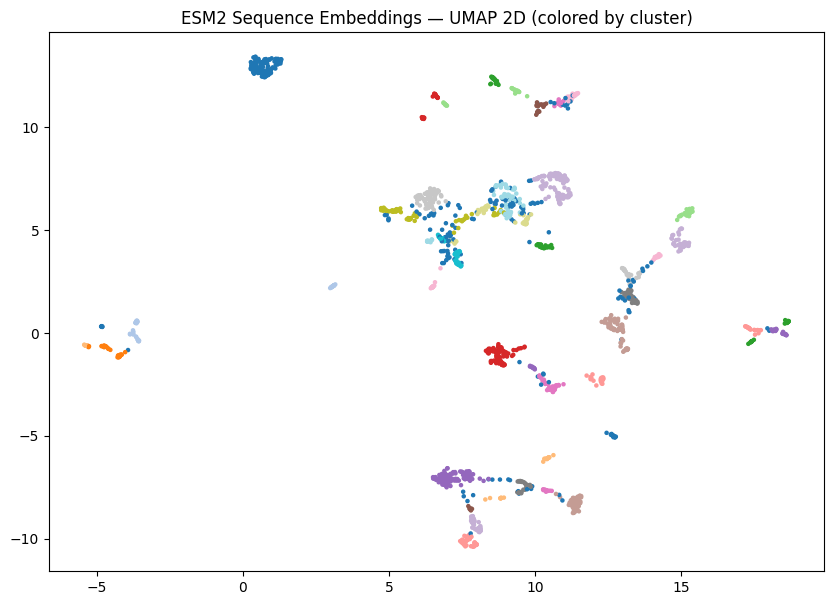

In [14]:
import matplotlib.pyplot as plt
reducer_2d = umap.UMAP(n_components=2, random_state=42, metric='cosine')
emb_2d = reducer_2d.fit_transform(df_normalized)

plt.figure(figsize=(10, 7))
plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=labels, cmap='tab20', s=5)
plt.title("ESM2 Sequence Embeddings — UMAP 2D (colored by cluster)")


#### Normalization way from this paper:

[Evaluating the significance of embedding-based protein sequence alignment with clustering and double dynamic programming for remote homology](https://www.nature.com/articles/s41598-025-23319-x)

##### Step 1 - Row-wise Z-score
Normalize each protein across its own 1280 embedding dimensions:

$$Z_r(i, d) = \frac{x_{i,d} - \mu_r(i)}{\sigma_r(i)}$$

##### Step 2 - Column-wise Z-score
Normalize each dimension across all 1999 proteins:

$$Z_c(i, d) = \frac{x_{i,d} - \mu_c(d)}{\sigma_c(d)}$$

##### Step 3 - Bidirectional Average
Average both Z-scores to produce the final normalized matrix:

$$SM'_{i,d} = \frac{Z_r(i,d) + Z_c(i,d)}{2}$$

This is the direct adaptation of the paper's formula: [nature](https://www.nature.com/articles/s41598-025-23319-x)

$$SM'_{a,b} = \frac{Z_r(a,b) + Z_c(a,b)}{2}$$

where in the paper \(a\) indexes residues of protein P and \(b\) indexes residues of protein Q — in your case \(i\) indexes proteins and \(d\) indexes embedding dimensions.

In [15]:

# Convert to numpy for efficient computation
X = embedding_sequences.values.astype(np.float64)  # shape: (1999, 1280)

# --- Step 1: Row-wise Z-score ---
# Normalize each protein across its own 1280 dimensions
row_mean = X.mean(axis=1, keepdims=True)  
row_std  = X.std(axis=1, keepdims=True)    
row_std[row_std == 0] = 1                  # avoid division by zero
Z_row = (X - row_mean) / row_std           

# --- Step 2: Column-wise Z-score ---
# Normalize each dimension across all 1999 proteins
col_mean = X.mean(axis=0, keepdims=True)   
col_std  = X.std(axis=0, keepdims=True)    
col_std[col_std == 0] = 1                  # avoid division by zero
Z_col = (X - col_mean) / col_std           # shape: (1999, 1280)

# --- Step 3: Average both (Ghanty et al. 2025 formula) ---
SM_prime = (Z_row + Z_col) / 2.0          # shape: (1999, 1280)

# --- Convert back to DataFrame ---
df_normalized_2 = pd.DataFrame(
    SM_prime,
    index=embedding_sequences.index
)

# df_normalized_2.to_csv("../data/processed/embedding_normalized_2.csv")
df_normalized_2.head()


,0,1,2,3,4,5,6,7,8,9,...,1270,1271,1272,1273,1274,1275,1276,1277,1278,1279
uniref_id,,,,,,,,,,,,,,,,,,,,,
P07550,0.737574,-0.748700,0.009087,0.225685,-0.058053,-0.373766,0.010101,0.682198,0.469299,0.218556,...,0.852384,0.396222,-0.402210,-0.633077,0.046169,0.045711,0.125008,0.272706,-0.526793,0.228714
A0A8D2HM49,0.703713,-0.784824,0.029224,0.454325,-0.067474,-0.279073,0.243852,0.860138,0.622273,0.293834,...,0.566616,0.446513,-0.523058,-0.481342,0.043023,0.112927,0.121897,0.281774,-0.509796,-0.056724
A0A250YHJ2,0.709364,-0.682475,0.133663,0.430044,0.148127,-0.352172,0.417931,1.018301,0.526313,0.428893,...,0.450850,0.418117,-0.588444,-0.488872,0.022373,0.075930,0.066354,0.192659,-0.465777,0.085538
A0A8C9AQU3,0.534155,-0.607607,-0.061139,0.197221,-0.035153,-0.339287,-0.052262,0.921377,0.357165,0.323804,...,0.581162,0.466746,-0.563764,-0.481847,-0.051385,0.170254,0.068136,0.049147,-0.412970,-0.013887
A0A8B7PU76,0.329860,-0.549984,0.037675,0.250074,0.081423,-0.257914,0.203307,0.800766,0.326138,0.465227,...,0.524565,0.310474,-0.362337,-0.553563,0.165769,0.123530,0.208823,0.107633,-0.389840,0.100769


In [16]:
reducer = umap.UMAP(n_components=50, random_state=42, metric='cosine')
embeddings_umap_2 = reducer.fit_transform(df_normalized_2)  # (N_proteins, 50)


c:\Users\win_10\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [17]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=5, metric='euclidean')
labels = clusterer.fit_predict(embeddings_umap_2)
# labels == -1 means noise/unclustered
print(f"Number of clusters found: {len(set(labels)) - (1 if -1 in labels else 0)}")
print(f"Number of noise points: {(labels == -1).sum()}")

Number of clusters found: 64
Number of noise points: 113


In [18]:
mask = labels != -1  # exclude noise points
sil = silhouette_score(embeddings_umap_2[mask], labels[mask])
db  = davies_bouldin_score(embeddings_umap_2[mask], labels[mask])
print(f"Silhouette: {sil:.4f} | Davies-Bouldin: {db:.4f}")


Silhouette: 0.6784 | Davies-Bouldin: 0.4197


c:\Users\win_10\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Text(0.5, 1.0, 'ESM2 Sequence Embeddings — UMAP 2D (colored by cluster)')

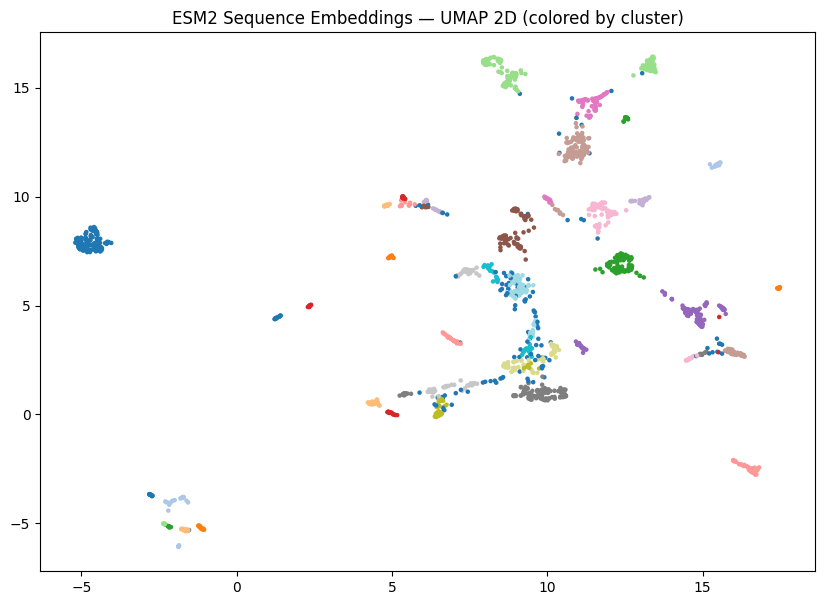

In [19]:
reducer_2d = umap.UMAP(n_components=2, random_state=42, metric='cosine')
emb_2d = reducer_2d.fit_transform(df_normalized_2)

plt.figure(figsize=(10, 7))
plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=labels, cmap='tab20', s=5)
plt.title("ESM2 Sequence Embeddings — UMAP 2D (colored by cluster)")


## Combine with textual data

In [21]:
textual_data = pd.read_csv("../data/processed/gpcr_text_clusters.csv", index_col=0)
textual_data = textual_data.drop(columns=['hybrid_cluster'])
data_with_embeddings = df_normalized_2.join(textual_data, how='inner')
data_with_embeddings.to_csv("../data/processed/data_with_embeddings.csv")
data_with_embeddings.head()

,0,1,2,3,4,5,6,7,8,9,...,1275,1276,1277,1278,1279,Protein names,Gene Names,Keywords,Gene Ontology (GO),Function [CC]
A0A8D2HM49,0.703713,-0.784824,0.029224,0.454325,-0.067474,-0.279073,0.243852,0.860138,0.622273,0.293834,...,0.112927,0.121897,0.281774,-0.509796,-0.056724,Beta-2 adrenergic receptor (Beta-2 adrenocepto...,ADRB2,Cell membrane;Disulfide bond;Endosome;G-protei...,apical plasma membrane [GO:0016324]; ciliary b...,FUNCTION: Beta-adrenergic receptors mediate th...
A0A250YHJ2,0.709364,-0.682475,0.133663,0.430044,0.148127,-0.352172,0.417931,1.018301,0.526313,0.428893,...,0.075930,0.066354,0.192659,-0.465777,0.085538,Beta-2 adrenergic receptor (Beta-2 adrenocepto...,ADRB2 Adrb2,Cell membrane;Disulfide bond;Endosome;G-protei...,early endosome [GO:0005769]; Golgi apparatus [...,FUNCTION: Beta-adrenergic receptors mediate th...
A0A8C9AQU3,0.534155,-0.607607,-0.061139,0.197221,-0.035153,-0.339287,-0.052262,0.921377,0.357165,0.323804,...,0.170254,0.068136,0.049147,-0.412970,-0.013887,Beta-2 adrenergic receptor (Beta-2 adrenocepto...,ADRB2,Cell membrane;Disulfide bond;Endosome;G-protei...,apical plasma membrane [GO:0016324]; ciliary b...,FUNCTION: Beta-adrenergic receptors mediate th...
A0A8B7PU76,0.329860,-0.549984,0.037675,0.250074,0.081423,-0.257914,0.203307,0.800766,0.326138,0.465227,...,0.123530,0.208823,0.107633,-0.389840,0.100769,Beta-2 adrenergic receptor (Beta-2 adrenocepto...,ADRB2,Cell membrane;Disulfide bond;Endosome;G-protei...,early endosome [GO:0005769]; Golgi apparatus [...,FUNCTION: Beta-adrenergic receptors mediate th...
A0A6I9I981,0.668424,-0.714338,0.284086,0.366246,-0.020887,-0.228616,0.167577,0.863712,0.491497,0.371577,...,0.132898,0.094181,0.314260,-0.478254,0.223390,Beta-2 adrenergic receptor (Beta-2 adrenocepto...,ADRB2,Cell membrane;Disulfide bond;Endosome;G-protei...,early endosome [GO:0005769]; Golgi apparatus [...,FUNCTION: Beta-adrenergic receptors mediate th...
